# 06. Trend Analysis: Languages (Job vs StackOverflow)

This notebook analyzes trends specifically for programming languages using:
1.  **Job Data**: `DataMining/data/job/topcv,jobspy/topcv_cong_nghe_thong_tin_jobs.csv`
2.  **StackOverflow Data**: `DataMining/pipeline_notebooks/data/stackoverflow_full_data.csv`

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 1. StackOverflow Data Analysis

Loaded StackOverflow Data: (7672347, 8)
         id                     creation_date  \
0  20869072  2014-01-01 13:23:42.980000+00:00   
1  20866033  2014-01-01 06:07:34.750000+00:00   
2  20876138  2014-01-02 04:02:02.927000+00:00   
3  20870202  2014-01-01 15:37:09.773000+00:00   
4  20872344  2014-01-01 19:26:41.197000+00:00   

                                               title  \
0                   Laravel Schema onDelete set null   
1  Starting emulator for AVD avd PANIC: Could not...   
2                 Close the app when back is pressed   
3  How to add Activity to manifest.xml in right way?   
4  Why does simple website crash on mobile (iOS S...   

                                                tags  view_count  score  \
0                     php|laravel|laravel-migrations      125184    157   
1                                android|eclipse|adt        7939      6   
2  android|android-layout|android-fragments|andro...         268      2   
3          android|android-a

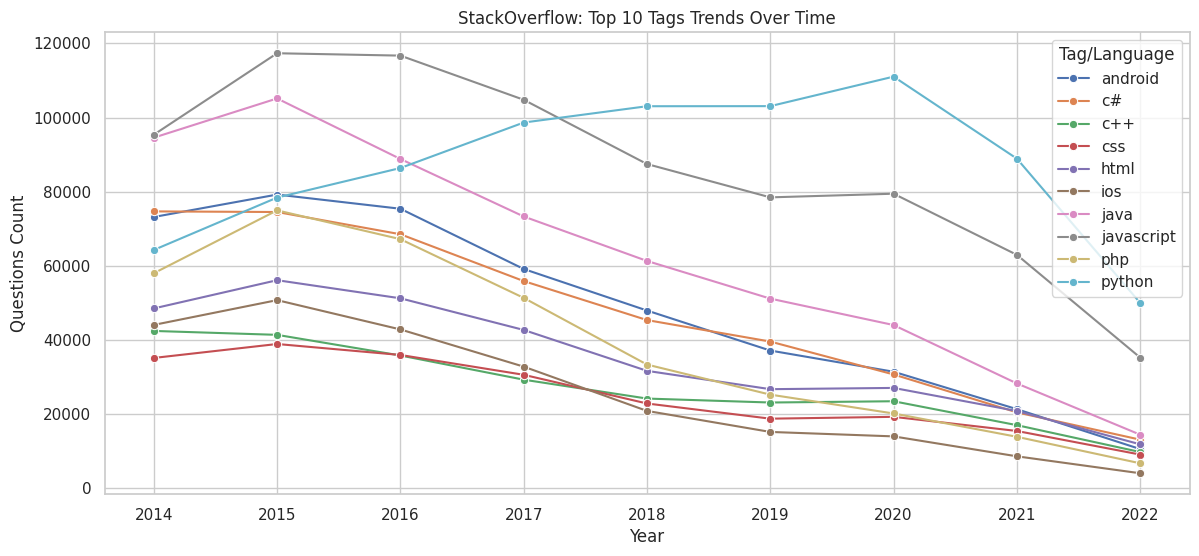

In [13]:
# Load SO Data
so_path = 'data/stackoverflow_full_data.csv'
so_df = pd.DataFrame()

try:
    so_df = pd.read_csv(so_path)
    print(f"Loaded StackOverflow Data: {so_df.shape}")
    print(so_df.head())
except FileNotFoundError:
    print(f"Error: {so_path} not found.")
    so_df = pd.DataFrame(columns=['creation_date', 'tags'])
except Exception as e:
    print(f"Error loading SO data: {e}")

# Preprocess SO
so_exploded = pd.DataFrame()

if not so_df.empty:
    try:
        # Parse Date
        so_df['creation_date'] = pd.to_datetime(so_df['creation_date'], errors='coerce')
        so_df['year'] = so_df['creation_date'].dt.year

        # Explode Tags
        so_df['tags'] = so_df['tags'].fillna('').str.split('|')
        so_exploded = so_df.explode('tags')
        
        if not so_exploded.empty and 'tags' in so_exploded.columns:
            # Count Top Tags
            so_tag_counts = so_exploded['tags'].value_counts()
            if not so_tag_counts.empty:
                so_top_tags = so_tag_counts.head(10).index.tolist()
                
                # Filter for top tags trends
                so_trend = so_exploded[so_exploded['tags'].isin(so_top_tags)]
                if not so_trend.empty:
                    so_trend_counts = so_trend.groupby(['year', 'tags']).size().reset_index(name='count')
                    
                    # Plot SO Trend
                    if not so_trend_counts.empty:
                        plt.figure(figsize=(14, 6))
                        sns.lineplot(data=so_trend_counts, x='year', y='count', hue='tags', marker='o')
                        plt.title('StackOverflow: Top 10 Tags Trends Over Time')
                        plt.xlabel('Year')
                        plt.ylabel('Questions Count')
                        plt.legend(title='Tag/Language')
                        plt.show()
                    else:
                        print("SO trend counts data frame is empty.")
                else:
                    print("No relevant trend data found for SO (after filtering top tags).")
            else:
                print("No tags found in SO data to count.")
        else:
            print("SO exploded dataframe is empty or lacks 'tags' column.")
    except Exception as e:
        print(f"Error processing SO data: {e}")
else:
    print("SO dataframe is empty.")

## 2. Job Data Analysis (TopCV)

Loaded Job Data: (1310, 25)
                                                  0   \
0                                              title   
1  Site Reliability Engineer (SRE/Devops)- Upto 1...   
2                               Junior – Senior Java   
3                                        IT Helpdesk   
4                         Frontend Reactjs Developer   

                                                  1   \
0                                       detail_title   
1  Site Reliability Engineer (SRE/ Devops )- Upto...   
2                               Junior – Senior Java   
3                                        IT Helpdesk   
4                         Frontend Reactjs Developer   

                                                  2   \
0                                            job_url   
1  https://www.topcv.vn/viec-lam/site-reliability...   
2  https://www.topcv.vn/viec-lam/junior-senior-ja...   
3  https://www.topcv.vn/viec-lam/it-helpdesk/1995...   
4  https://www.top

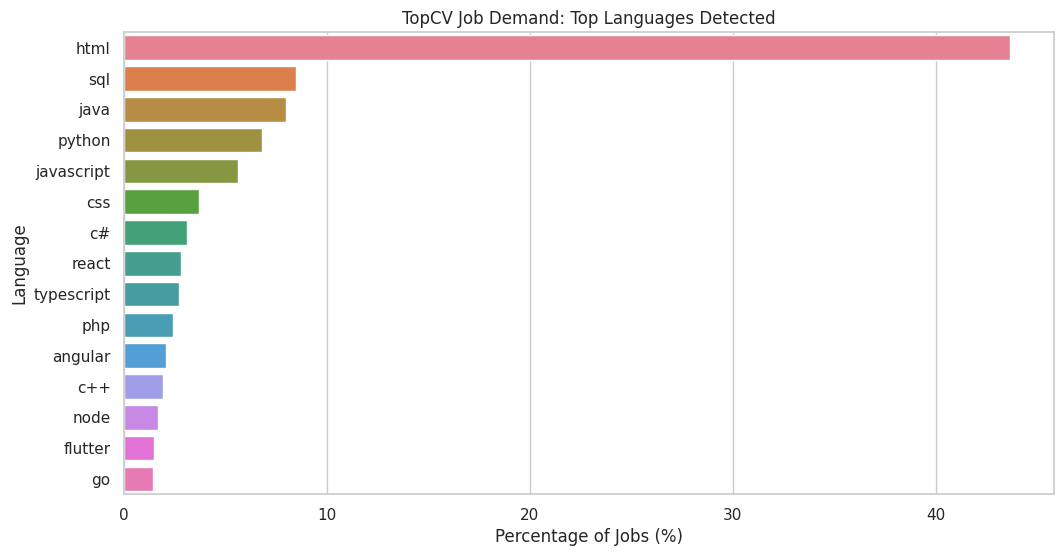

In [14]:
# Load Job Data
job_path = './data/topcv_cong_nghe_thong_tin_jobs.csv'
job_df = pd.DataFrame()

try:
    # Reading without header first to inspect
    job_df = pd.read_csv(job_path, header=None, on_bad_lines='skip')
    print(f"Loaded Job Data: {job_df.shape}")
    if not job_df.empty:
        print(job_df.head())
except FileNotFoundError:
    print(f"Error: {job_path} not found.")
except Exception as e:
    print(f"Error reading job file: {e}")

# Keyword Extraction Logic
target_languages = [
    'python', 'java', 'javascript', 'c++', 'c#', 'php', 'ruby', 'go', 'swift', 'kotlin', 
    'typescript', 'rust', 'html', 'css', 'sql', 'react', 'angular', 'vue', 'node', 'flutter'
]

def extract_languages(text):
    if pd.isna(text):
        return []
    found = []
    text_lower = str(text).lower()
    for lang in target_languages:
        try:
            if re.search(r'\b' + re.escape(lang) + r'\b', text_lower):
                found.append(lang)
            elif lang in ['c++', 'c#'] and lang in text_lower:
                 if lang == 'c++' and 'c++' in text_lower: found.append(lang)
                 if lang == 'c#' and 'c#' in text_lower: found.append(lang)
        except Exception:
            continue
    return list(set(found))

job_lang_counts = pd.Series(dtype=int)

if not job_df.empty:
    try:
        # Assuming column 13/14/15 contains description/requirements based on preview
        print("Processing job data for languages...")
        
        # Concatenate all string columns to search for keywords (brute force but effective for raw unknown schema)
        # Avoid numeric columns
        str_cols = job_df.select_dtypes(include=['object']).columns
        if len(str_cols) > 0:
            job_df['combined_text'] = job_df[str_cols].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)
            
            job_df['extracted_languages'] = job_df['combined_text'].apply(extract_languages)
            
            job_exploded = job_df.explode('extracted_languages')
            job_exploded = job_exploded[job_exploded['extracted_languages'].notna()]
            
            if not job_exploded.empty:
                # Count
                job_lang_counts = job_exploded['extracted_languages'].value_counts(normalize=True) * 100
                
                print("Top Job Languages found:")
                print(job_lang_counts.head())

                # Plot Job Demand (snapshot)
                if not job_lang_counts.empty:
                    try:
                        plt.figure(figsize=(12, 6))
                        top_n = min(15, len(job_lang_counts))
                        if top_n > 0:
                            plot_data = job_lang_counts.head(top_n)
                            sns.barplot(x=plot_data.values, y=plot_data.index, hue=plot_data.index, legend=False)
                            plt.title('TopCV Job Demand: Top Languages Detected')
                            plt.xlabel('Percentage of Jobs (%)')
                            plt.ylabel('Language')
                            plt.show()
                        else:
                            print("Not enough data to plot job trends.")
                    except Exception as e:
                        print(f"Error plotting Job Data: {e}")
                else:
                     print("job_lang_counts is empty.")
            else:
                 print("No languages found in job descriptions.")
        else:
            print("No string columns found in Job DataFrame.")
    except Exception as e:
        print(f"Error processing Job data: {e}")
else:
    print("Job DataFrame is empty.")

## 3. Comparison (SO Volume vs Job Demand)
Comparing the *current* usage in SO vs Job Demand.

Comparing SO and Job Data...
Comparison Data Head:
            StackOverflow (Interest)  Job (Demand)
html                        1.224874     43.633333
sql                         0.605910      8.466667
java                        1.600202      7.966667
python                      5.196616      6.800000
javascript                  3.674771      5.600000


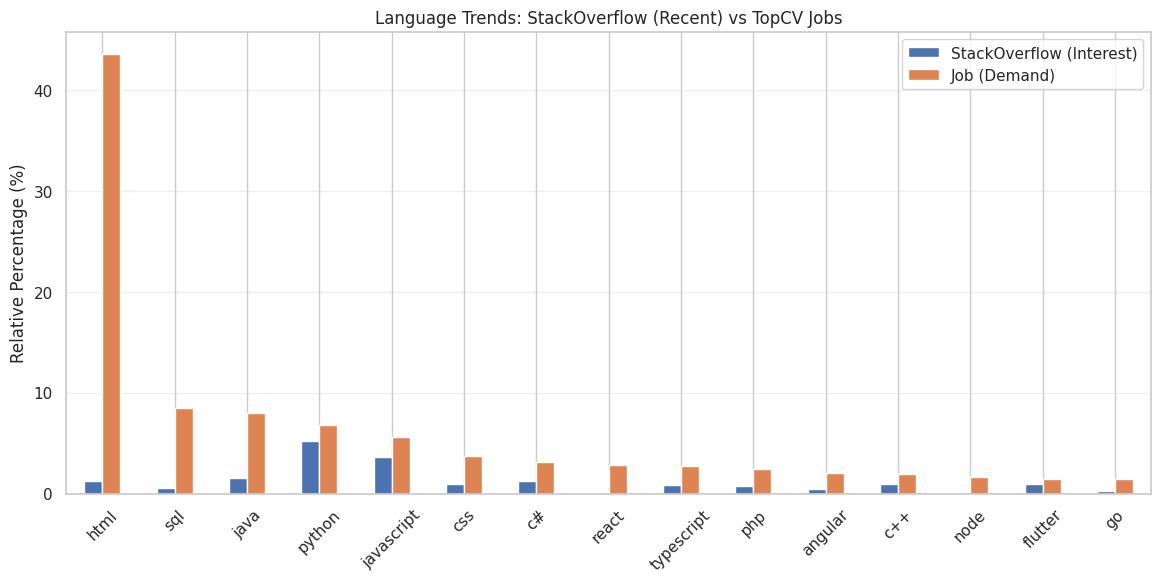

In [15]:
try:
    if not so_df.empty and not job_lang_counts.empty:
        print("Comparing SO and Job Data...")
        # Filter SO for recent years (e.g., last 2 years) if year column exists
        if 'year' in so_df.columns and not so_df['year'].isnull().all():
            recent_year = so_df['year'].max()
            so_recent = so_exploded[so_exploded['year'] >= recent_year - 1]
        else:
            so_recent = so_exploded # Fallback to all if year is missing

        if not so_recent.empty:
            so_recent_counts = so_recent['tags'].value_counts(normalize=True) * 100
            
            # Align Data
            # Using `target_languages` to filter SO tags
            so_filtered_counts = so_recent_counts[so_recent_counts.index.isin(target_languages)]
            
            # Create Comparison DF only if intersection exists
            if not so_filtered_counts.empty:
                # Align indices
                common_langs = list(set(so_filtered_counts.index) | set(job_lang_counts.index))
                
                so_aligned = so_filtered_counts.reindex(common_langs).fillna(0)
                job_aligned = job_lang_counts.reindex(common_langs).fillna(0)

                comparison_df = pd.DataFrame({
                    'StackOverflow (Interest)': so_aligned,
                    'Job (Demand)': job_aligned
                }) # Sorting is removed here to avoid potential empty index error on empty DF
                
                if not comparison_df.empty:
                    comparison_df = comparison_df.sort_values(by='Job (Demand)', ascending=False)
                    print("Comparison Data Head:")
                    print(comparison_df.head())
                    
                    # Plot
                    comparison_df.head(15).plot(kind='bar', figsize=(14, 6))
                    plt.title(f'Language Trends: StackOverflow (Recent) vs TopCV Jobs')
                    plt.ylabel('Relative Percentage (%)')
                    plt.xticks(rotation=45)
                    plt.grid(axis='y', alpha=0.3)
                    plt.show()
                else:
                    print("Comparison DataFrame is empty after alignment.")
            else:
                 print("No matching target languages found in recent SO data.")
        else:
            print("No recent SO data found.")
    else:
        print("Cannot compare: One or both datasets are empty or processed incorrectly.")
except Exception as e:
    print(f"Error during comparison visualization: {e}")
    import traceback
    traceback.print_exc()